In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pingouin as pg
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/thiennguyen37-qn/hypothesis_testing/refs/heads/main/data/magnus_carlsen_all_online_games_cleaned.csv")
df['opponent_color'] = df['opponent_color'].str.lower()
df['player_color'] = df['player_color'].str.lower()
df = df[(df['year'] > 2020) & (df['year'] < 2026)]
df = df.sort_values(by='date')
df = df[df['format'] == 'Blitz']
df = df.dropna()
df = df.reset_index(drop=True)
df = df.drop(columns=['opponent_name','opponent_color','player_rating','player_name','result_raw','date','format','moves'])
df

,opponent_rating,player_color,result,year
0,2816.0,black,Win,2021
1,2838.0,black,Win,2021
2,2836.0,white,Draw,2021
3,2839.0,black,Win,2021
4,2836.0,white,Win,2021
...,...,...,...,...
9869,3073.0,white,Loss,2025
9870,2974.0,white,Win,2025
9871,2677.0,white,Win,2025
9872,3242.0,white,Win,2025


In [ ]:
alpha = 0.05

# =========================
# 1. Tạo bảng tần số (contingency table)
# =========================
contingency_table = pd.crosstab(df["player_color"], df["result"])
display(contingency_table)

# =========================
# 2. Thực hiện kiểm định Chi-square
# =========================
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

# =========================
# 3. Expected frequencies
# =========================
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)
display(expected_df)

# =========================
# 4. Kết luận
# =========================
if p_value < alpha:
    print("\nReject H0: There's a relationship between player_color and result")

else:
    print("\nFail to reject H0")

result,Draw,Loss,Win
player_color,,,
black,447,1115,3368
white,359,919,3666



Chi-square statistic: 41.100059739295666
Degrees of freedom: 2
P-value: 1.1891466717081915e-09


result,Draw,Loss,Win
player_color,,,
black,402.4286,1015.558031,3512.013368
white,403.5714,1018.441969,3521.986632



Reject H0: There's a relationship between player_color and result


<Axes: xlabel='opponent_rating'>

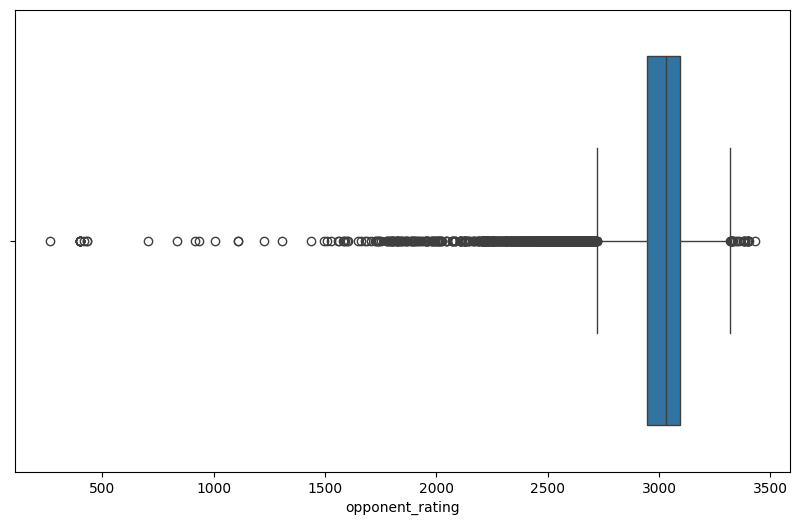

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='opponent_rating', data=df)

In [ ]:
# Apply Winsorization to 'opponent_rating'
# Limits: 5% from the lower end, 5% from the upper end
winsorized_rating = winsorize(df['opponent_rating'], limits=[0.05, 0.05])


# Convert the winsorized data back to a pandas Series and add it to the DataFrame
df['opponent_rating_winsorized'] = winsorized_rating

print("Descriptive statistics for original opponent_rating and winsorized opponent_rating:")
original_stats = df['opponent_rating'].describe()
winsorized_stats = df['opponent_rating_winsorized'].describe()

# Combine the two Series into a single DataFrame for comparison
comparison_df = pd.DataFrame({
    'Original Opponent Rating': original_stats,
    'Winsorized Opponent Rating': winsorized_stats
})

display(comparison_df)

Descriptive statistics for original opponent_rating and winsorized opponent_rating:


,Original Opponent Rating,Winsorized Opponent Rating
count,9874.000000,9874.000000
mean,2976.441462,2991.300182
std,242.539043,165.225366
min,265.000000,2535.000000
25%,2945.250000,2945.250000
50%,3031.000000,3031.000000
75%,3095.000000,3095.000000
max,3429.000000,3198.000000


<Axes: xlabel='opponent_rating_winsorized'>

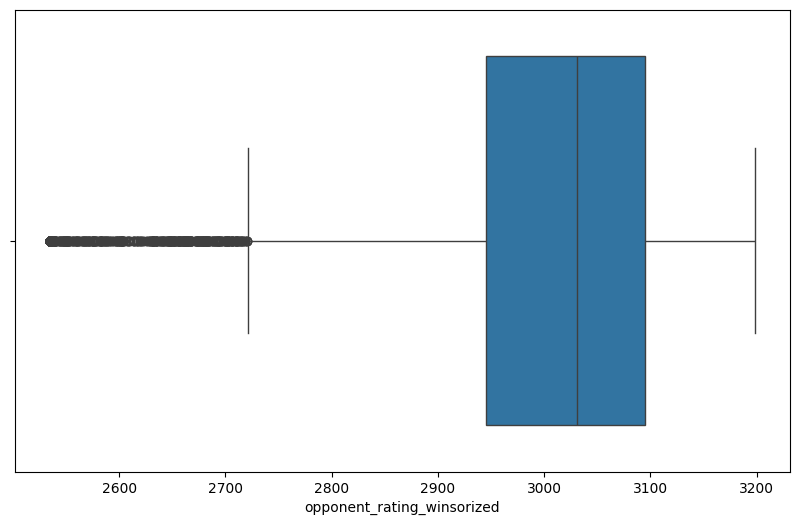

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='opponent_rating_winsorized', data=df)

In [ ]:
def welch_ttest(col):
  df_filtered = df[df['result'].isin(['Win', 'Loss'])]
  win_group = df_filtered[df_filtered['result'] == 'Win'][col]
  loss_group = df_filtered[df_filtered['result'] == 'Loss'][col]
  t_stat_all, p_val_all = stats.ttest_ind(win_group, loss_group, equal_var=False)
  print(f"Trung bình Elo nhóm Win:  {win_group.mean():.2f}")
  print(f"Trung bình Elo nhóm Loss: {loss_group.mean():.2f}")
  print(f"T-statistic: {t_stat_all:.4f}, P-value: {p_val_all:.5e}")
  if p_val_all < 0.05:
      print("-> Kết luận: Có sự khác biệt ý nghĩa thống kê về Elo trung bình khi Thắng và Thua.\n")
  else:
      print("-> Kết luận: KHÔNG có sự khác biệt ý nghĩa về Elo trung bình giữa trận Thắng và Thua.")


welch_ttest('opponent_rating')
welch_ttest('opponent_rating_winsorized')

Trung bình Elo nhóm Win:  2946.96
Trung bình Elo nhóm Loss: 3045.35
T-statistic: -21.5318, P-value: 3.57195e-99
-> Kết luận: Có sự khác biệt ý nghĩa thống kê về Elo trung bình khi Thắng và Thua.

Trung bình Elo nhóm Win:  2968.68
Trung bình Elo nhóm Loss: 3044.04
T-statistic: -21.4406, P-value: 4.15045e-97
-> Kết luận: Có sự khác biệt ý nghĩa thống kê về Elo trung bình khi Thắng và Thua.



In [ ]:
import pandas as pd
from scipy import stats

def welch_ttest_df(col, label):
    df_filtered = df[df['result'].isin(['Win', 'Loss'])]

    win_group = df_filtered[df_filtered['result'] == 'Win'][col]
    loss_group = df_filtered[df_filtered['result'] == 'Loss'][col]

    t_stat, p_val = stats.ttest_ind(win_group, loss_group, equal_var=False)

    return pd.DataFrame({
        'Metric': ['Mean (Win)', 'Mean (Loss)', 'Std (Win)', 'Std (Loss)', 'N (Win)', 'N (Loss)', 't-stat', 'p-value'],
        label: [
            win_group.mean(),
            loss_group.mean(),
            win_group.std(),
            loss_group.std(),
            win_group.count(),
            loss_group.count(),
            t_stat,
            p_val
        ]
    })
df_original = welch_ttest_df('opponent_rating', 'Original')
df_winsor = welch_ttest_df('opponent_rating_winsorized', 'Winsorized')

result_df = df_original.merge(df_winsor, on='Metric')

result_df.style.format({
    'Original': lambda x: f"{x:.4e}" if 'p-value' in result_df.loc[result_df['Original'] == x, 'Metric'].values else f"{x:.2f}",
    'Winsorized': lambda x: f"{x:.4e}" if 'p-value' in result_df.loc[result_df['Winsorized'] == x, 'Metric'].values else f"{x:.2f}"
})

,Metric,Original,Winsorized
0,Mean (Win),2946.96,2968.68
1,Mean (Loss),3045.35,3044.04
2,Std (Win),266.88,174.10
3,Std (Loss),147.91,127.90
4,N (Win),7034.00,7034.00
5,N (Loss),2034.00,2034.00
6,t-stat,-21.53,-21.44
7,p-value,3.5719e-99,4.1505e-97


In [ ]:
# 1. Chạy Welch's ANOVA cho 5 năm
# dv: biến định lượng (opponent_rating), between: biến phân loại (year)
alpha = 0.05
anova_year = pg.welch_anova(dv='opponent_rating', between='year', data=df)

print("--- KẾT QUẢ WELCH'S ANOVA THEO NĂM ---")
print(anova_year)

# 2. Nếu p-value < 0.05, chạy Post-hoc để so sánh từng cặp năm
if anova_year['p_unc'].values[0] < alpha:
    posthoc_year = pg.pairwise_gameshowell(dv='opponent_rating', between='year', data=df)
    print("\n--- SO SÁNH CHI TIẾT GIỮA CÁC NĂM (POST-HOC) ---")
    # Hiển thị các cặp có sự khác biệt rõ rệt (p-value < 0.05)
    significant_diff = posthoc_year[posthoc_year['pval'] < alpha]
    significant_diff.drop(columns=['se','df'], inplace=True)
    significant_diff.reset_index(drop=True, inplace=True)
    display(significant_diff)

--- KẾT QUẢ WELCH'S ANOVA THEO NĂM ---
  Source  ddof1        ddof2          F         p_unc       np2
0   year      4  4506.209935  21.505922  1.354568e-17  0.006025

--- SO SÁNH CHI TIẾT GIỮA CÁC NĂM (POST-HOC) ---


,A,B,mean_A,mean_B,diff,T,pval,hedges
0,2021,2022,2961.928153,3016.867340,-54.939186,-8.354920,6.972201e-14,-0.245440
1,2021,2025,2961.928153,2984.225954,-22.297801,-2.972466,2.477507e-02,-0.088274
2,2022,2023,3016.867340,2959.814881,57.052459,7.567194,1.772360e-12,0.268594
3,2022,2024,3016.867340,2977.125708,39.741632,5.032539,5.071462e-06,0.173646
4,2022,2025,3016.867340,2984.225954,32.641385,4.136348,3.484577e-04,0.136087
5,2023,2025,2959.814881,2984.225954,-24.411073,-2.920278,2.897486e-02,-0.095848
